# P-spline-Only Affine-Shift Experiment

This notebook fits **only** `PositivePrecisionPSplineFullVI`.

The data are generated from a Leroux spatial field on the true rook-lattice Laplacian. The fitted operator preserves the true eigenvectors and shifts only the positive eigenvalues:

$$
\mu_1 = 0,
\qquad
\mu_i = A + \lambda_i, \quad i \geq 2,
$$

with `AFFINE_SCALE_B = 1.00`.

The notebook performs two distinct checks:

1. **Direct representational check:** Fit the P-spline directly to the known target precision. This tests whether the spline family can represent the target curve.
2. **Likelihood-based VI fit:** Estimate the same P-spline from one noisy spatial realization with a centered holdout block. This tests statistical recovery and prediction.

No fitted Leroux model, Leroux initialization, or right-natural boundary subclass is used.


## 1. Imports and project path

In [75]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import torch

from IPython.display import display

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import PositivePrecisionPSplineFullVI
from sdmcar.models_holdout import SpectralCAR_HoldoutVI

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

print("Project root:", ROOT)
print("Device:", DEVICE)

Project root: C:\Users\pd006\Desktop\internship_search\sdm-car
Device: cpu


## 2. Locked configuration

In [76]:
SEED = 0

N_ROWS = 20
N_COLS = 20
N = N_ROWS * N_COLS

TAU2_TRUE = 0.70
RHO_TRUE = 0.92
BETA_TRUE = 0.0
SIGMA2_TRUE = 0.15

HOLDOUT_SIDE = 10

# Change only A when studying misspecification difficulty.
AFFINE_SHIFT_A = 1.00
AFFINE_SCALE_B = 1.00

FIX_SIGMA2 = True
NUM_MC = 8
PRED_MC = 512
GRAD_CLIP = 10.0

PSPLINE_ITERS = 6000
PSPLINE_LR = 3e-4

DIRECT_ITERS = 4000
DIRECT_LR = 2e-2

# Fixed, truth-independent initialization used for every A and seed.
INIT_Q_LEFT = 0.20
INIT_Q_RIGHT = 5.00

CURVATURE_PRIOR_STD = 0.50

PSPLINE_KWARGS = {
    "degree": 3,
    "n_internal_knots": 4,
    "prior_std_log_q": 3.0,
    "prior_std_d2": CURVATURE_PRIOR_STD,
    "log_std_log_q": -3.0,
    "log_std_d2": -3.0,
    "init_d2": 0.0,
    "log_q_min": -20.0,
    "log_q_max": 20.0,
}

print(
    "Curvature prior SD:",
    PSPLINE_KWARGS["prior_std_d2"],
)

np.random.seed(SEED)
torch.manual_seed(SEED)

A_CRITICAL = (1.0 - RHO_TRUE) / RHO_TRUE

print("Nodes:", N)
print("Seed:", SEED)
print("Affine shift A:", AFFINE_SHIFT_A)
print("Affine scale B:", AFFINE_SCALE_B)
print(f"Theoretical Leroux boundary: {A_CRITICAL:.6f}")
print(
    "Regime:",
    "inside exact Leroux family"
    if AFFINE_SHIFT_A < A_CRITICAL
    else "outside exact Leroux family",
)

Curvature prior SD: 0.5
Nodes: 400
Seed: 0
Affine shift A: 1.0
Affine scale B: 1.0
Theoretical Leroux boundary: 0.086957
Regime: outside exact Leroux family


## 3. True rook graph and warped eigenvalues

In [77]:
def node_index(row, col):
    return row * N_COLS + col


def build_rook_adjacency():
    W = np.zeros((N, N), dtype=float)

    for row in range(N_ROWS):
        for col in range(N_COLS):
            i = node_index(row, col)

            if col + 1 < N_COLS:
                j = node_index(row, col + 1)
                W[i, j] = W[j, i] = 1.0

            if row + 1 < N_ROWS:
                j = node_index(row + 1, col)
                W[i, j] = W[j, i] = 1.0

    np.fill_diagonal(W, 0.0)
    return W


def graph_laplacian(W):
    degree = W.sum(axis=1)
    L = np.diag(degree) - W
    return 0.5 * (L + L.T)


def affine_shift_positive_modes(
    lam,
    shift,
    scale=1.0,
    zero_tolerance=1e-8,
):
    if shift < 0.0:
        raise ValueError("shift must be nonnegative.")
    if scale <= 0.0:
        raise ValueError("scale must be positive.")

    lam = np.asarray(lam, dtype=float)
    warped = np.zeros_like(lam)
    positive = lam > zero_tolerance
    warped[positive] = shift + scale * lam[positive]
    return warped


W_true = build_rook_adjacency()
L_true = graph_laplacian(W_true)

lam_true, U_true = np.linalg.eigh(L_true)
lam_true = np.clip(lam_true, 0.0, None)

lam_warp = affine_shift_positive_modes(
    lam_true,
    shift=AFFINE_SHIFT_A,
    scale=AFFINE_SCALE_B,
)

# Controlled experiment: eigenvectors remain correct.
U_warp = U_true.copy()

positive_true_mask = lam_true > 1e-8
positive_warp_mask = lam_warp > 1e-8

print("Undirected edges:", np.count_nonzero(W_true) // 2)
print("True eigenvalue range:", (lam_true.min(), lam_true.max()))
print("Warped eigenvalue range:", (lam_warp.min(), lam_warp.max()))
print(
    "Smallest positive true eigenvalue:",
    lam_true[positive_true_mask].min(),
)
print(
    "Smallest positive warped eigenvalue:",
    lam_warp[positive_warp_mask].min(),
)

Undirected edges: 760
True eigenvalue range: (np.float64(5.337428614855639e-16), np.float64(7.950753362380551))
Warped eigenvalue range: (np.float64(0.0), np.float64(8.950753362380551))
Smallest positive true eigenvalue: 0.024623318809725358
Smallest positive warped eigenvalue: 1.0246233188097253


## 4. Simulate one Leroux spatial field

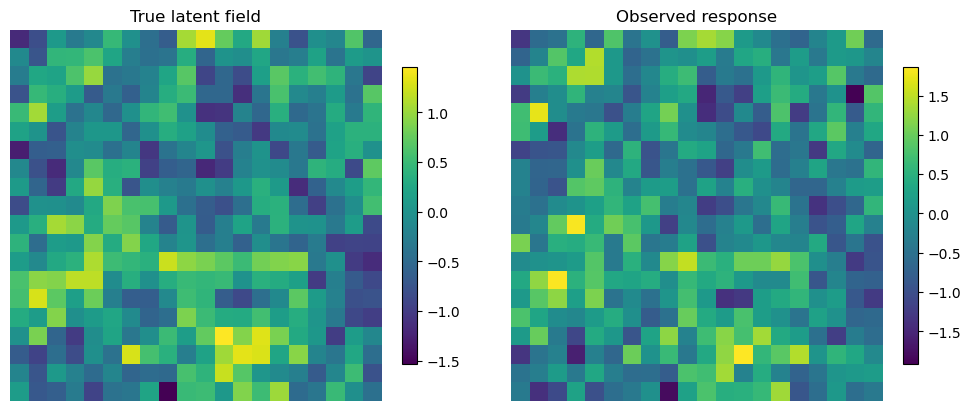

In [78]:
rng = np.random.default_rng(SEED)

# True covariance spectrum in the true eigenbasis.
F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = U_true @ (
    np.sqrt(F_true)
    * rng.normal(size=N)
)

eta_true = BETA_TRUE + phi_true

y = eta_true + rng.normal(
    loc=0.0,
    scale=np.sqrt(SIGMA2_TRUE),
    size=N,
)

# Because U_warp = U_true, this is also the target modal
# covariance under the warped operator ordering.
target_covariance = F_true.copy()
target_precision = 1.0 / target_covariance

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

image_0 = axes[0].imshow(
    eta_true.reshape(N_ROWS, N_COLS)
)
axes[0].set_title("True latent field")
axes[0].axis("off")
fig.colorbar(image_0, ax=axes[0], shrink=0.8)

image_1 = axes[1].imshow(
    y.reshape(N_ROWS, N_COLS)
)
axes[1].set_title("Observed response")
axes[1].axis("off")
fig.colorbar(image_1, ax=axes[1], shrink=0.8)

plt.show()

## 5. Holdout block and tensors

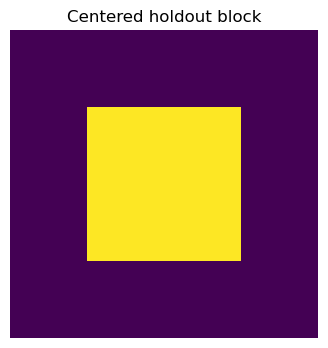

Training nodes: 300
Held-out nodes: 100


In [79]:
def centered_block_mask(side):
    mask = np.zeros((N_ROWS, N_COLS), dtype=bool)

    row_start = (N_ROWS - side) // 2
    col_start = (N_COLS - side) // 2

    mask[
        row_start:row_start + side,
        col_start:col_start + side,
    ] = True

    return mask.ravel()


def graph_tensors(lam, U):
    return (
        torch.tensor(
            np.clip(lam, 0.0, None),
            dtype=torch.double,
            device=DEVICE,
        ),
        torch.tensor(
            U,
            dtype=torch.double,
            device=DEVICE,
        ),
    )


test_mask = centered_block_mask(HOLDOUT_SIDE)
train_mask = ~test_mask

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=DEVICE,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

y_test_t = y_all_t[is_holdout_t].clone()

y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = 10.0 * torch.eye(
    1,
    dtype=torch.double,
    device=DEVICE,
)

lam_warp_t, U_warp_t = graph_tensors(
    lam_warp,
    U_warp,
)

plt.figure(figsize=(4.5, 4))
plt.imshow(test_mask.reshape(N_ROWS, N_COLS))
plt.title("Centered holdout block")
plt.axis("off")
plt.show()

print("Training nodes:", int(train_mask.sum()))
print("Held-out nodes:", int(test_mask.sum()))

## 6. P-spline factory

In [80]:
def make_precision_spline_filter(lam_t):
    return PositivePrecisionPSplineFullVI(
        lam_max=float(lam_t.max().item()),
        mu_log_q_left=math.log(INIT_Q_LEFT),
        mu_log_q_right=math.log(INIT_Q_RIGHT),
        **PSPLINE_KWARGS,
    ).to(DEVICE)


filter_check = make_precision_spline_filter(lam_warp_t)
print("Spline basis functions J:", filter_check.J)
print("Second-difference parameters K:", filter_check.K)

Spline basis functions J: 8
Second-difference parameters K: 6


## 7. Direct representational-capacity check

This fit sees the known target precision and therefore does **not** measure statistical recovery. It answers only whether the P-spline family can represent the target at the supplied warped eigenvalues.

In [81]:
def direct_filter_theta(filter_module):
    theta = {
        "log_q_left": filter_module.mu_log_q_endpoints[0:1],
        "log_q_right": filter_module.mu_log_q_endpoints[1:2],
    }

    for j in range(filter_module.K):
        theta[f"d2_{j}_raw"] = filter_module.mu_d2[j:j + 1]

    return theta


def log_spectrum_rmse(estimated, target, mask=None):
    estimated = np.asarray(estimated, dtype=float)
    target = np.asarray(target, dtype=float)

    if mask is not None:
        estimated = estimated[mask]
        target = target[mask]

    estimated = np.clip(estimated, 1e-12, None)
    target = np.clip(target, 1e-12, None)

    return float(
        np.sqrt(
            np.mean(
                (
                    np.log(estimated)
                    - np.log(target)
                ) ** 2
            )
        )
    )


direct_filter = make_precision_spline_filter(lam_warp_t)
q_target_t = torch.tensor(
    target_precision,
    dtype=torch.double,
    device=DEVICE,
)

direct_optimizer = torch.optim.Adam(
    [
        direct_filter.mu_log_q_endpoints,
        direct_filter.mu_d2,
    ],
    lr=DIRECT_LR,
)

direct_loss_history = []

for iteration in range(1, DIRECT_ITERS + 1):
    direct_optimizer.zero_grad(set_to_none=True)

    theta_direct = direct_filter_theta(direct_filter)
    q_direct_t = direct_filter.precision_from_unconstrained(
        lam_warp_t,
        theta_direct,
    )

    direct_loss = torch.mean(
        (
            torch.log(q_direct_t)
            - torch.log(q_target_t)
        ) ** 2
    )

    direct_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            direct_filter.mu_log_q_endpoints,
            direct_filter.mu_d2,
        ],
        max_norm=10.0,
    )

    direct_optimizer.step()
    direct_loss_history.append(float(direct_loss.detach().cpu()))

    if iteration == 1 or iteration % 500 == 0:
        print(
            f"Direct iteration {iteration:4d} | "
            f"log-MSE={direct_loss_history[-1]:.8f}"
        )

with torch.no_grad():
    theta_direct = direct_filter_theta(direct_filter)
    q_direct_fit = (
        direct_filter
        .precision_from_unconstrained(
            lam_warp_t,
            theta_direct,
        )
        .detach()
        .cpu()
        .numpy()
    )

F_direct_fit = 1.0 / np.clip(q_direct_fit, 1e-12, None)

direct_summary = direct_filter.shrinkage_summary()

direct_metrics = pd.DataFrame(
    [
        {
            "A": AFFINE_SHIFT_A,
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left_target": target_precision[np.argmin(lam_warp)],
            "q_left_direct": q_direct_fit[np.argmin(lam_warp)],
            "q_right_target": target_precision[np.argmax(lam_warp)],
            "q_right_direct": q_direct_fit[np.argmax(lam_warp)],
            "d2_l2": float(direct_summary["d2_l2"].cpu()),
        }
    ]
)

display(direct_metrics)

Direct iteration    1 | log-MSE=0.37082187
Direct iteration  500 | log-MSE=0.01589215
Direct iteration 1000 | log-MSE=0.00975527
Direct iteration 1500 | log-MSE=0.00837322
Direct iteration 2000 | log-MSE=0.00785149
Direct iteration 2500 | log-MSE=0.00762503
Direct iteration 3000 | log-MSE=0.00748007
Direct iteration 3500 | log-MSE=0.00735047
Direct iteration 4000 | log-MSE=0.00722944


,A,log_spectrum_rmse_all,log_spectrum_rmse_positive,q_left_target,q_left_direct,q_right_target,q_right_direct,d2_l2
0,1.0,0.085025,0.085041,0.114286,0.105701,10.563847,10.845964,5.315067


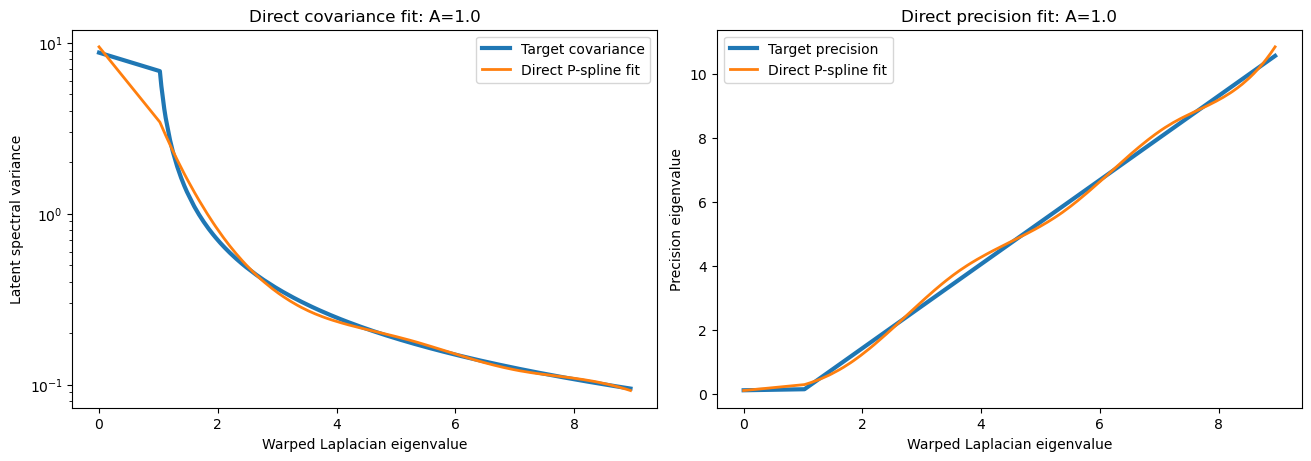

In [82]:
order = np.argsort(lam_warp)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_covariance[order],
    linewidth=3,
    label="Target covariance",
)
axes[0].plot(
    lam_warp[order],
    F_direct_fit[order],
    linewidth=2,
    label="Direct P-spline fit",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Warped Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(f"Direct covariance fit: A={AFFINE_SHIFT_A}")
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)
axes[1].plot(
    lam_warp[order],
    q_direct_fit[order],
    linewidth=2,
    label="Direct P-spline fit",
)
axes[1].set_xlabel("Warped Laplacian eigenvalue")
axes[1].set_ylabel("Precision eigenvalue")
axes[1].set_title(f"Direct precision fit: A={AFFINE_SHIFT_A}")
axes[1].legend()

plt.show()

## 8. Likelihood-based P-spline fit

This fit uses only the training observations. It measures whether one noisy spatial realization contains enough information to recover the target spectrum and predict the held-out block.

In [83]:
def fit_pspline_vi(
    *,
    lam_t,
    U_t,
    iterations,
    learning_rate,
    seed,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    filter_module = make_precision_spline_filter(lam_t)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=(
            SIGMA2_TRUE if FIX_SIGMA2 else None
        ),
        jitter=1e-8,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    history = []

    for iteration in range(1, iterations + 1):
        optimizer.zero_grad(set_to_none=True)

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at iteration {iteration}."
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        optimizer.step()
        history.append(float(elbo.detach().cpu()))

        if iteration % 500 == 0:
            recent = float(np.mean(history[-100:]))
            print(
                f"P-spline VI: {iteration}/{iterations}, "
                f"recent ELBO={recent:.3f}"
            )

    torch.manual_seed(seed + 10_000)

    prediction = model.predict_vi_mc(num_mc=PRED_MC)
    metrics = model.score_predictions(
        y_test=y_test_t,
        prediction=prediction,
    )

    return {
        "model": model,
        "prediction": prediction,
        "metrics": metrics,
        "history": history,
        "lam_t": lam_t,
        "U_t": U_t,
    }


pspline_result = fit_pspline_vi(
    lam_t=lam_warp_t,
    U_t=U_warp_t,
    iterations=PSPLINE_ITERS,
    learning_rate=PSPLINE_LR,
    seed=SEED,
)

print("P-spline VI fit complete.")

P-spline VI: 500/6000, recent ELBO=-44.470
P-spline VI: 1000/6000, recent ELBO=-42.481
P-spline VI: 1500/6000, recent ELBO=-41.287
P-spline VI: 2000/6000, recent ELBO=-40.638
P-spline VI: 2500/6000, recent ELBO=-39.926
P-spline VI: 3000/6000, recent ELBO=-39.537
P-spline VI: 3500/6000, recent ELBO=-38.950
P-spline VI: 4000/6000, recent ELBO=-38.892
P-spline VI: 4500/6000, recent ELBO=-38.649
P-spline VI: 5000/6000, recent ELBO=-38.316
P-spline VI: 5500/6000, recent ELBO=-38.093
P-spline VI: 6000/6000, recent ELBO=-38.101
P-spline VI fit complete.


## 9. Prediction metrics

In [84]:
prediction_mean = (
    pspline_result["prediction"]["mean"]
    .detach()
    .cpu()
    .numpy()
)

eta_rmse = float(
    np.sqrt(
        np.mean(
            (
                prediction_mean
                - eta_true[test_mask]
            ) ** 2
        )
    )
)

prediction_results = pd.DataFrame(
    [
        {
            "model": "Precision P-spline SDM-CAR",
            "A": AFFINE_SHIFT_A,
            "test_y_rmse": float(
                pspline_result["metrics"]["rmse"]
            ),
            "test_y_mae": float(
                pspline_result["metrics"]["mae"]
            ),
            "test_eta_rmse": eta_rmse,
        }
    ]
)

display(prediction_results)

,model,A,test_y_rmse,test_y_mae,test_eta_rmse
0,Precision P-spline SDM-CAR,1.0,0.593002,0.471809,0.506732


## 10. Posterior spectrum and curvature diagnostics

In [85]:
@torch.no_grad()
def plugin_spectrum(result):
    theta_mean = result["model"].filter.mean_unconstrained()

    return (
        result["model"]
        .filter
        .spectrum(result["lam_t"], theta_mean)
        .detach()
        .cpu()
        .numpy()
    )


@torch.no_grad()
def posterior_spectrum_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_000,
):
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie between 0 and 1."
        )

    torch.manual_seed(seed)
    spectra = []

    for _ in range(draws):
        theta = result["model"].filter.sample_unconstrained()
        spectra.append(
            result["model"]
            .filter
            .spectrum(result["lam_t"], theta)
        )

    spectra = torch.stack(spectra, dim=0)
    tail = (1.0 - credible_level) / 2.0

    summaries = (
        spectra.mean(dim=0),
        torch.quantile(spectra, tail, dim=0),
        torch.quantile(spectra, 1.0 - tail, dim=0),
    )

    return tuple(
        value.detach().cpu().numpy()
        for value in summaries
    )


@torch.no_grad()
def posterior_precision_components_summary(
    result,
    draws=512,
    credible_level=0.95,
    seed=20_002,
):
    """
    Monte Carlo posterior summaries for:

        q_full(lambda; theta)
        q_affine(lambda; theta)
        log_correction(lambda; theta)

    This computes E[q(theta)], not q(E[theta]).
    """
    if not 0.0 < credible_level < 1.0:
        raise ValueError(
            "credible_level must lie between 0 and 1."
        )

    torch.manual_seed(seed)

    model = result["model"]
    filt = model.filter
    lam_t = result["lam_t"]

    q_full_draws = []
    q_affine_draws = []
    log_correction_draws = []

    for _ in range(draws):
        theta = filt.sample_unconstrained()

        q_full_draws.append(
            filt.precision_from_unconstrained(
                lam_t,
                theta,
            )
        )

        q_affine_draws.append(
            filt.affine_precision_from_unconstrained(
                lam_t,
                theta,
            )
        )

        log_correction_draws.append(
            filt.correction_from_unconstrained(
                lam_t,
                theta,
            )
        )

    q_full_draws = torch.stack(
        q_full_draws,
        dim=0,
    )

    q_affine_draws = torch.stack(
        q_affine_draws,
        dim=0,
    )

    log_correction_draws = torch.stack(
        log_correction_draws,
        dim=0,
    )

    tail = (1.0 - credible_level) / 2.0

    def summarize(draws_t):
        return {
            "mean": draws_t.mean(dim=0),
            "lower": torch.quantile(
                draws_t,
                tail,
                dim=0,
            ),
            "upper": torch.quantile(
                draws_t,
                1.0 - tail,
                dim=0,
            ),
        }

    q_full_summary = summarize(q_full_draws)
    q_affine_summary = summarize(q_affine_draws)
    correction_summary = summarize(
        log_correction_draws
    )

    def to_numpy(x):
        return x.detach().cpu().numpy()

    return {
        "q_full_mean": to_numpy(
            q_full_summary["mean"]
        ),
        "q_full_lower": to_numpy(
            q_full_summary["lower"]
        ),
        "q_full_upper": to_numpy(
            q_full_summary["upper"]
        ),
        "q_affine_mean": to_numpy(
            q_affine_summary["mean"]
        ),
        "q_affine_lower": to_numpy(
            q_affine_summary["lower"]
        ),
        "q_affine_upper": to_numpy(
            q_affine_summary["upper"]
        ),
        "log_correction_mean": to_numpy(
            correction_summary["mean"]
        ),
        "log_correction_lower": to_numpy(
            correction_summary["lower"]
        ),
        "log_correction_upper": to_numpy(
            correction_summary["upper"]
        ),
    }


F_vi_plugin = plugin_spectrum(pspline_result)
(
    F_vi_mean,
    F_vi_lower,
    F_vi_upper,
) = posterior_spectrum_summary(
    pspline_result,
    draws=512,
    seed=20_001,
)

precision_posterior = (
    posterior_precision_components_summary(
        pspline_result,
        draws=512,
        credible_level=0.95,
        seed=20_002,
    )
)

q_vi_mean = precision_posterior["q_full_mean"]
q_vi_lower = precision_posterior["q_full_lower"]
q_vi_upper = precision_posterior["q_full_upper"]

q_vi_affine_mean = precision_posterior[
    "q_affine_mean"
]

q_vi_affine_lower = precision_posterior[
    "q_affine_lower"
]

q_vi_affine_upper = precision_posterior[
    "q_affine_upper"
]

vi_log_correction_mean = precision_posterior[
    "log_correction_mean"
]

vi_log_correction_lower = precision_posterior[
    "log_correction_lower"
]

vi_log_correction_upper = precision_posterior[
    "log_correction_upper"
]

vi_shrinkage = (
    pspline_result["model"]
    .filter
    .shrinkage_summary()
)

spectral_diagnostics = pd.DataFrame(
    [
        {
            "fit": "Direct target fit",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_direct_fit,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_direct_fit[np.argmin(lam_warp)],
            "q_right": q_direct_fit[np.argmax(lam_warp)],
            "d2_l2": float(
                direct_summary["d2_l2"].cpu()
            ),
        },
        {
            "fit": "Likelihood VI posterior mean",
            "log_spectrum_rmse_all": log_spectrum_rmse(
                F_vi_mean,
                target_covariance,
            ),
            "log_spectrum_rmse_positive": log_spectrum_rmse(
                F_vi_mean,
                target_covariance,
                positive_warp_mask,
            ),
            "q_left": q_vi_mean[np.argmin(lam_warp)],
            "q_right": q_vi_mean[np.argmax(lam_warp)],
            "d2_l2": float(
                vi_shrinkage["d2_l2"].cpu()
            ),
        },
        {
            "fit": "Target",
            "log_spectrum_rmse_all": 0.0,
            "log_spectrum_rmse_positive": 0.0,
            "q_left": target_precision[np.argmin(lam_warp)],
            "q_right": target_precision[np.argmax(lam_warp)],
            "d2_l2": np.nan,
        },
    ]
)

display(spectral_diagnostics)

print(
    "Maximum absolute posterior-mean log correction:",
    float(
        np.max(
            np.abs(vi_log_correction_mean)
        )
    ),
)

,fit,log_spectrum_rmse_all,log_spectrum_rmse_positive,q_left,q_right,d2_l2
0,Direct target fit,0.085025,0.085041,0.105701,10.845964,5.315067
1,Likelihood VI posterior mean,0.223113,0.223379,0.119217,6.794560,0.656288
2,Target,0.000000,0.000000,0.114286,10.563847,NaN


Maximum absolute posterior-mean log correction: 0.483182448309766


## 11. Target, direct-fit, and likelihood-fit spectra

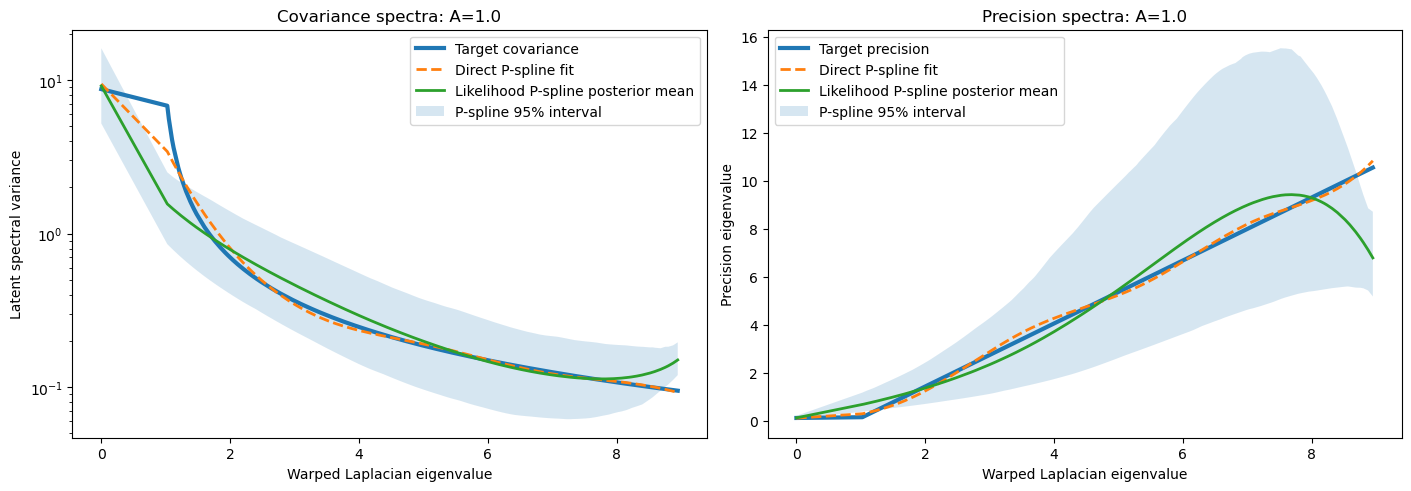

In [86]:
# q_vi_lower = 1.0 / np.clip(F_vi_upper, 1e-12, None)
# q_vi_upper = 1.0 / np.clip(F_vi_lower, 1e-12, None)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].plot(
    lam_warp[order],
    target_covariance[order],
    linewidth=3,
    label="Target covariance",
)
axes[0].plot(
    lam_warp[order],
    F_direct_fit[order],
    linestyle="--",
    linewidth=2,
    label="Direct P-spline fit",
)
axes[0].plot(
    lam_warp[order],
    F_vi_mean[order],
    linewidth=2,
    label="Likelihood P-spline posterior mean",
)
axes[0].fill_between(
    lam_warp[order],
    F_vi_lower[order],
    F_vi_upper[order],
    alpha=0.18,
    label="P-spline 95% interval",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("Warped Laplacian eigenvalue")
axes[0].set_ylabel("Latent spectral variance")
axes[0].set_title(f"Covariance spectra: A={AFFINE_SHIFT_A}")
axes[0].legend()

axes[1].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)
axes[1].plot(
    lam_warp[order],
    q_direct_fit[order],
    linestyle="--",
    linewidth=2,
    label="Direct P-spline fit",
)
axes[1].plot(
    lam_warp[order],
    q_vi_mean[order],
    linewidth=2,
    label="Likelihood P-spline posterior mean",
)
axes[1].fill_between(
    lam_warp[order],
    q_vi_lower[order],
    q_vi_upper[order],
    alpha=0.18,
    label="P-spline 95% interval",
)
axes[1].set_xlabel("Warped Laplacian eigenvalue")
axes[1].set_ylabel("Precision eigenvalue")
axes[1].set_title(f"Precision spectra: A={AFFINE_SHIFT_A}")
axes[1].legend()

plt.show()

## 12. Affine baseline and learned nonlinear correction

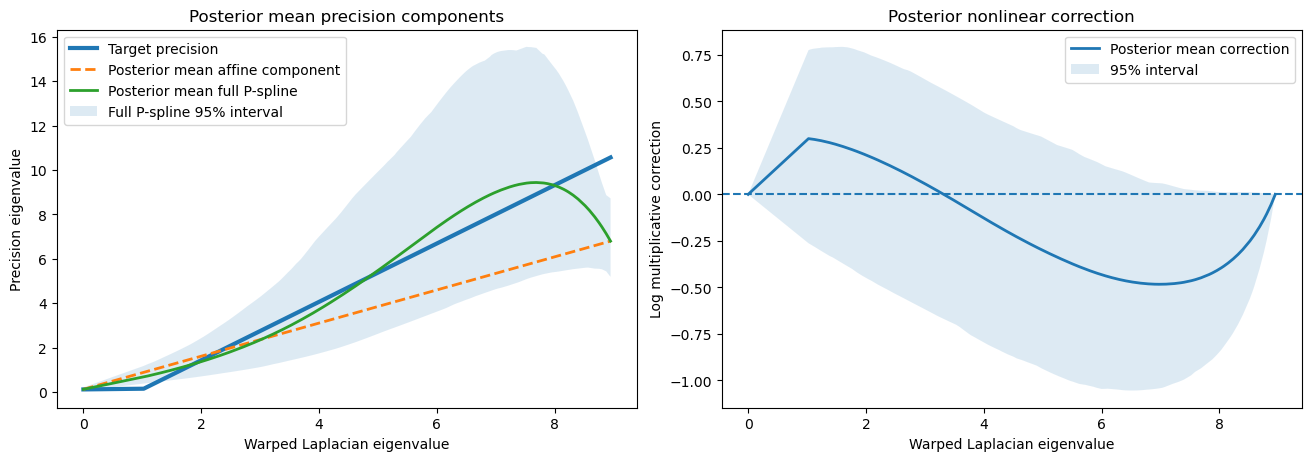

In [87]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    constrained_layout=True,
)

# ---------------------------------------------------------
# Posterior mean precision components
# ---------------------------------------------------------
axes[0].plot(
    lam_warp[order],
    target_precision[order],
    linewidth=3,
    label="Target precision",
)

axes[0].plot(
    lam_warp[order],
    q_vi_affine_mean[order],
    linestyle="--",
    linewidth=2,
    label="Posterior mean affine component",
)

axes[0].plot(
    lam_warp[order],
    q_vi_mean[order],
    linewidth=2,
    label="Posterior mean full P-spline",
)

axes[0].fill_between(
    lam_warp[order],
    q_vi_lower[order],
    q_vi_upper[order],
    alpha=0.15,
    label="Full P-spline 95% interval",
)

axes[0].set_xlabel(
    "Warped Laplacian eigenvalue"
)
axes[0].set_ylabel("Precision eigenvalue")
axes[0].set_title(
    "Posterior mean precision components"
)
axes[0].legend()

# ---------------------------------------------------------
# Posterior mean nonlinear correction
# ---------------------------------------------------------
axes[1].plot(
    lam_warp[order],
    vi_log_correction_mean[order],
    linewidth=2,
    label="Posterior mean correction",
)

axes[1].fill_between(
    lam_warp[order],
    vi_log_correction_lower[order],
    vi_log_correction_upper[order],
    alpha=0.15,
    label="95% interval",
)

axes[1].axhline(
    0.0,
    linestyle="--",
)

axes[1].set_xlabel(
    "Warped Laplacian eigenvalue"
)
axes[1].set_ylabel(
    "Log multiplicative correction"
)
axes[1].set_title(
    "Posterior nonlinear correction"
)
axes[1].legend()

plt.show()

In [88]:
right = np.argmax(lam_warp)
left = np.argmin(lam_warp)

print("LEFT ENDPOINT")
print(f"Target:         {target_precision[left]:.6f}")
print(f"Posterior mean: {q_vi_mean[left]:.6f}")
print(
    "95% interval:  "
    f"({q_vi_lower[left]:.6f}, "
    f"{q_vi_upper[left]:.6f})"
)

print("\nRIGHT ENDPOINT")
print(f"Target:         {target_precision[right]:.6f}")
print(f"Posterior mean: {q_vi_mean[right]:.6f}")
print(
    "95% interval:  "
    f"({q_vi_lower[right]:.6f}, "
    f"{q_vi_upper[right]:.6f})"
)

print(
    "\nTarget inside right-endpoint interval:",
    bool(
        q_vi_lower[right]
        <= target_precision[right]
        <= q_vi_upper[right]
    ),
)

LEFT ENDPOINT
Target:         0.114286
Posterior mean: 0.119217
95% interval:  (0.064137, 0.203366)

RIGHT ENDPOINT
Target:         10.563847
Posterior mean: 6.794560
95% interval:  (5.183239, 8.721542)

Target inside right-endpoint interval: False


## 13. Held-out latent-field reconstruction

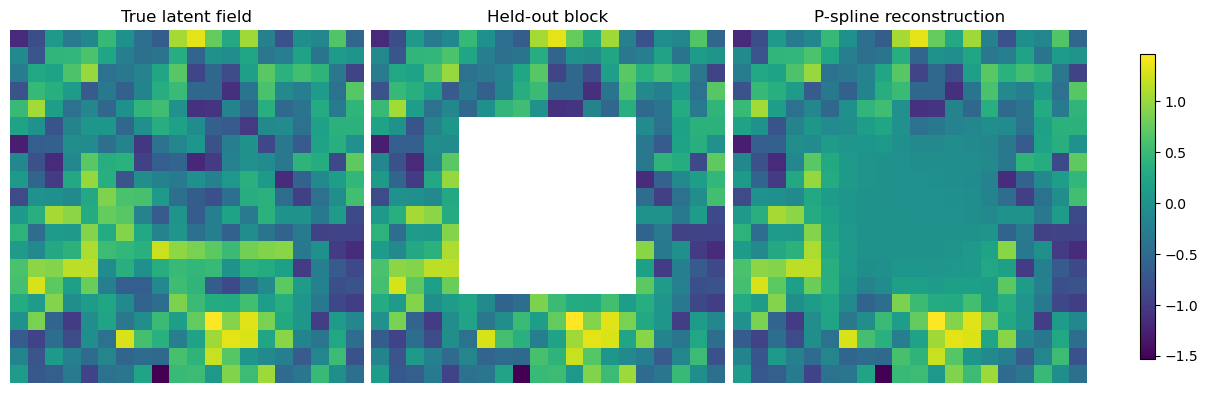

In [89]:
completed = eta_true.copy()
completed[test_mask] = prediction_mean

masked = eta_true.copy()
masked[test_mask] = np.nan

fields = [
    eta_true.reshape(N_ROWS, N_COLS),
    masked.reshape(N_ROWS, N_COLS),
    completed.reshape(N_ROWS, N_COLS),
]

titles = [
    "True latent field",
    "Held-out block",
    "P-spline reconstruction",
]

finite_values = np.concatenate(
    [field[np.isfinite(field)] for field in fields]
)

vmin = finite_values.min()
vmax = finite_values.max()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
    constrained_layout=True,
)

for ax, field, title in zip(axes, fields, titles):
    image = ax.imshow(field, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(image, ax=axes, shrink=0.8)
plt.show()

## 14. Optimization diagnostics

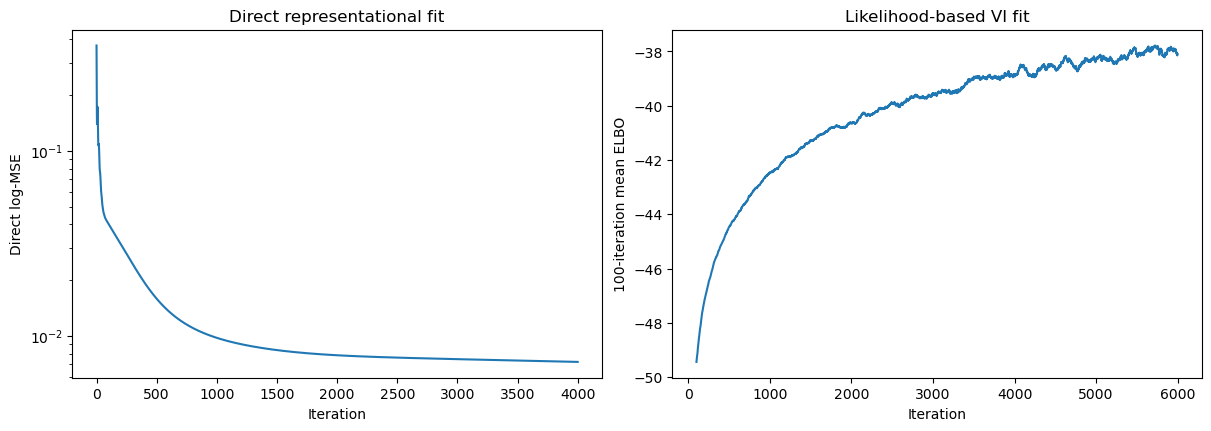

In [90]:
history = np.asarray(pspline_result["history"])
smoothed = pd.Series(history).rolling(100).mean()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.2),
    constrained_layout=True,
)

axes[0].plot(direct_loss_history)
axes[0].set_yscale("log")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Direct log-MSE")
axes[0].set_title("Direct representational fit")

axes[1].plot(smoothed)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("100-iteration mean ELBO")
axes[1].set_title("Likelihood-based VI fit")

plt.show()

## How to interpret the results

- At `AFFINE_SHIFT_A = 0`, the target precision is affine. The direct-fit error should be very small and the likelihood-fit curvature norm should remain small.
- If the direct fit is accurate but the likelihood fit is not, the limitation is **statistical recovery**, not P-spline flexibility.
- As `AFFINE_SHIFT_A` increases, compare the fitted curvature norm and log-spectrum RMSE. The P-spline should depart from its affine component only when the data support the correction.
- Use exactly the same initialization, priors, graph, data seed, and holdout while changing only `AFFINE_SHIFT_A`.

Suggested diagnostic sequence:

```python
AFFINE_SHIFT_A = 0.00
AFFINE_SHIFT_A = 0.15
AFFINE_SHIFT_A = 0.50
AFFINE_SHIFT_A = 1.00
AFFINE_SHIFT_A = 2.00
```